# Titanic Survival Prediction

## 2a.

### Problem
Predict whether a passenger survived the Titanic sinking (binary: 0 = did not
survive, 1 = survived), using passenger attributes available at booking time —
class, sex, age, fare, family aboard, and port of embarkation.

### Why F1, not just accuracy
The target is imbalanced: roughly 62% did not survive, 38% did. A model that
predicts "did not survive" for everyone scores ~62% accuracy while learning
nothing. Accuracy alone would hide that.

F1 balances precision and recall on the positive class (survived), so a model
that ignores the minority class gets penalized instead of rewarded. This
notebook uses F1 as the primary metric, with accuracy and a confusion matrix
reported alongside it for context — not instead of it.

### What "done" looks like
- A single trained model, evaluated on a held-out test set, with F1 and
  accuracy reported.
- A confusion matrix showing where it fails (false negatives vs false
  positives), because in this dataset those errors aren't equally
  interesting — missing an actual survivor (false negative) vs wrongly
  calling a non-survivor a survivor are different kinds of mistakes worth
  looking at separately.
- One clear written conclusion that matches the printed numbers, not a
  restatement of the metric name.


## 2b. Load data + sanity checks

Loading the raw CSV as-is, no cleaning yet. The point of this section is just to confirm the data matches what's expected before doing anything to it — shape, column types, and where the missing values actually are.

In [15]:
import pandas as pd

df = pd.read_csv("../data/TitanicDataset.csv")
df.shape

(891, 12)

In [16]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Checking missing values explicitly rather than relying on `.info()` alone — `.info()` shows non-null counts per column, but a sorted percentage view makes it obvious which columns actually need a decision (impute, drop, or leave alone) in the cleaning step.

In [18]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


## 2c. EDA

Baseline first, then one plot per question. Each plot should answer something specific — no scratch exploration left in the final notebook.

In [19]:
df['Survived'].value_counts(normalize=True).round(3)

Survived
0    0.616
1    0.384
Name: proportion, dtype: float64

Baseline: ~38% survived. Anything below this a model could get by always predicting "died" — worth keeping in mind when judging model performance later.

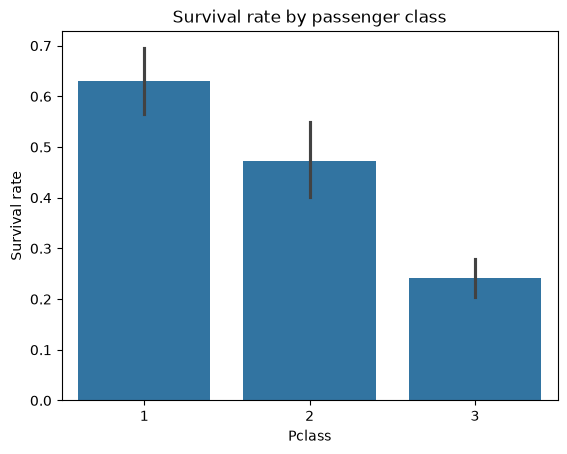

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df, x='Pclass', y='Survived')
plt.title('Survival rate by passenger class')
plt.ylabel('Survival rate')
plt.show()

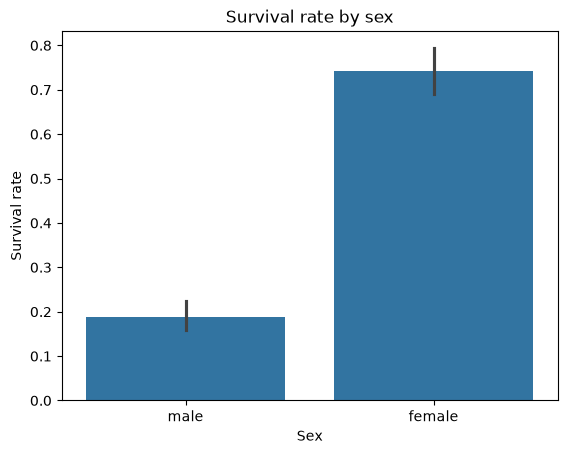

In [21]:
sns.barplot(data=df, x='Sex', y='Survived')
plt.title('Survival rate by sex')
plt.ylabel('Survival rate')
plt.show()

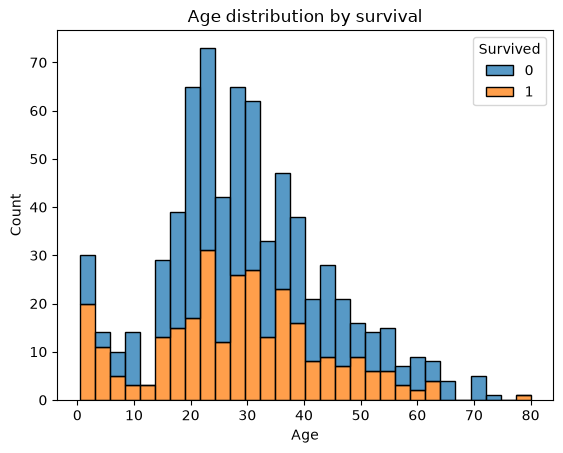

In [22]:
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', bins=30)
plt.title('Age distribution by survival')
plt.show()

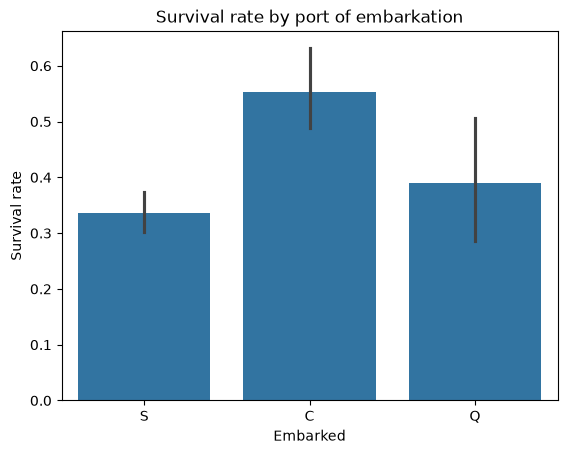

In [23]:
sns.barplot(data=df, x='Embarked', y='Survived')
plt.title('Survival rate by port of embarkation')
plt.ylabel('Survival rate')
plt.show()

## 2d. Cleaning

Three columns have missing values: Cabin (77.1%), Age (19.9%), Embarked (0.2%). Each gets a different treatment because the missingness is different in each case.

- **Cabin**: drop it. At 77% missing, there's no reasonable way to impute it without mostly inventing data, and it's redundant with Pclass anyway (cabin letter roughly maps to class).
- **Age**: impute with the median *within each Pclass/Sex group*, not a single dataset-wide median. Age correlates with both — 1st class male median is 40, 3rd class female median is 21.5 — so a flat median would systematically distort both ends. Median (not mean) within each group for the same right-skew reason as before.
- **Embarked**: impute with the mode. Only 2 rows missing, negligible effect either way.

In [26]:
df_clean = df.drop(columns=['Cabin'])

df_clean['Age'] = df_clean.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

embarked_mode = df_clean['Embarked'].mode()[0]
df_clean['Embarked'] = df_clean['Embarked'].fillna(embarked_mode)

In [27]:
df_clean.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 2e. Feature engineering

Dropping columns that don't carry usable signal, then encoding what's left.

- **Drop PassengerId**: pure row index, no signal.
- **Drop Name**: not usable as-is. Titles (Mr/Mrs/Miss) buried in the string do correlate with survival, but extracting them is an enhancement beyond scope here — keeping this light per the project convention.
- **Drop Ticket**: alphanumeric ticket codes with no consistent structure, mostly noise.
- **Encode Sex**: binary, map to 0/1.
- **Encode Embarked**: one-hot, since it's an unordered category (no Q > S > C ranking implied).
- **Keep Pclass as-is**: already an ordered integer (1/2/3), no encoding needed.

In [28]:
df_features = df_clean.drop(columns=['PassengerId', 'Name', 'Ticket'])

df_features['Sex'] = df_features['Sex'].map({'male': 0, 'female': 1})

df_features = pd.get_dummies(df_features, columns=['Embarked'], drop_first=True)

df_features.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [29]:
df_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(2), float64(2), int64(5)
memory usage: 50.6 KB


## 2f. Train/test split

Splitting before any model touches the data, and stratifying on `Survived`.

**Why stratify:** the 38/62 class split from 2c is moderate but real. A random (non-stratified) split can, by chance, land at something like 34/66 in train and 43/57 in test — enough drift to make F1 comparisons across models noisy for reasons that have nothing to do with the models. Stratifying forces both train and test to keep the same ~38/62 ratio as the full dataset, so any F1 difference between models is actually about the models.

`random_state=42` for reproducibility — same split every time this notebook is rerun.

In [30]:
from sklearn.model_selection import train_test_split

X = df_features.drop(columns=['Survived'])
y = df_features['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape

((712, 8), (179, 8))

In [31]:
print(y_train.value_counts(normalize=True).round(3))
print(y_test.value_counts(normalize=True).round(3))

Survived
0    0.617
1    0.383
Name: proportion, dtype: float64
Survived
0    0.615
1    0.385
Name: proportion, dtype: float64


## 2g. Baseline model

Logistic regression, no tuning. The point of a baseline isn't to be good — it's to set a floor. Every model tried after this either beats it or it doesn't earn a place in the comparison in 2h.

`max_iter=1000` because the default (100) doesn't always converge on this feature set — that's a solver setting, not a hyperparameter choice, so no tuning happening here.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train, y_train)
baseline_preds = baseline.predict(X_test)

baseline_f1 = f1_score(y_test, baseline_preds)
baseline_acc = accuracy_score(y_test, baseline_preds)

print(f"F1: {baseline_f1:.3f}")
print(f"Accuracy: {baseline_acc:.3f}")

F1: 0.744
Accuracy: 0.816


## 2h. Model comparison

Comparing three models against the logistic regression baseline: Random Forest and SVM. Kept the set small and deliberate rather than throwing every sklearn classifier at it — the goal is a considered choice, not an exhaustive search.

Each model is wrapped in a `Pipeline` with `StandardScaler`. This matters more than it looks: SVM is distance-based, so an unscaled `Fare` (0–512) completely dominates an unscaled `Age` (0–80) or the 0/1 columns, and SVM's F1 collapses to 0.45 without scaling. Random Forest doesn't care about scale (it splits on thresholds, not distances), but wrapping every model the same way keeps the comparison fair and removes one variable.

5-fold stratified cross-validation on the training set only — `X_test`/`y_test` stay untouched until 2i. Scoring is F1, per the decision in 2a.

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')
    cv_results[name] = scores
    print(f"{name}: {scores.mean():.3f} +/- {scores.std():.3f}")

Logistic Regression: 0.734 +/- 0.030
Random Forest: 0.757 +/- 0.023
SVM: 0.741 +/- 0.031


## 2i. Evaluation

Fitting each model (same scaled pipeline as 2h) on the full training set and scoring on `X_test`/`y_test` — the untouched holdout from 2f. This is the number that actually decides the winner, not the cross-validation mean from 2h.

Worth noting up front: this can (and does) disagree with the CV ranking. CV averages performance across folds of the training data; the test set is one specific 179-row sample. A model can look best on average across folds and still not be the best on this particular holdout. The test set result is what's reported here since it's the realistic held-out check.

In [37]:
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

test_results = {}
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    test_results[name] = {
        'f1': f1_score(y_test, preds),
        'accuracy': accuracy_score(y_test, preds)
    }
    fitted_models[name] = pipe

pd.DataFrame(test_results).T.round(3)

,f1,accuracy
Logistic Regression,0.750,0.821
Random Forest,0.727,0.799
SVM,0.717,0.810


In [35]:
winner_name = max(test_results, key=lambda k: test_results[k]['f1'])
winner_model = fitted_models[winner_name]
print(f"Winner: {winner_name} (F1 = {test_results[winner_name]['f1']:.3f})")

Winner: Logistic Regression (F1 = 0.750)


In [38]:
winner_preds = winner_model.predict(X_test)
print(classification_report(y_test, winner_preds))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.70      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



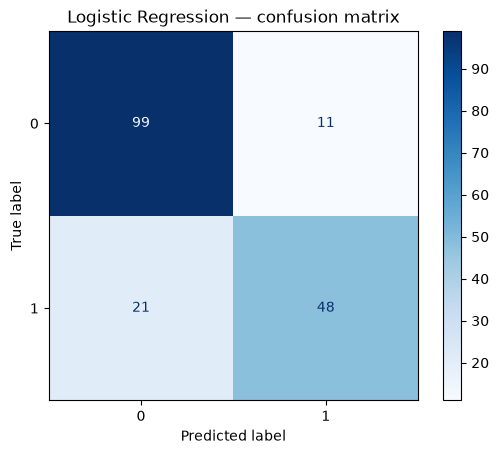

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, winner_preds, cmap='Blues')
plt.title(f'{winner_name} — confusion matrix')
plt.show()

## 2j. Results summary

**Problem:** predict Titanic passenger survival (binary classification) from Pclass, Sex, Age, SibSp, Parch, Fare, and Embarked.

**Approach:** median-imputed Age (grouped by Pclass/Sex) and mode-imputed Embarked, dropped Cabin/Name/Ticket/PassengerId, one-hot encoded Embarked, binary-encoded Sex. Compared Logistic Regression, Random Forest, and SVM — all wrapped in the same `StandardScaler` pipeline for a fair comparison.

**Result:** Logistic Regression won on the held-out test set with **F1 = 0.750, accuracy = 0.821**, ahead of Random Forest (F1 = 0.727) and SVM (F1 = 0.717). This is despite Random Forest scoring higher on cross-validation (0.757 vs 0.734) — the test-set result is what's reported, per the reasoning in 2i.

On the confusion matrix: the model catches 48 of 69 actual survivors (recall 0.70) and correctly rejects 99 of 110 non-survivors. It's more likely to miss a survivor than to falsely predict one — worth keeping in mind if this were used for anything higher-stakes than a portfolio demo.

**Exported for the FastAPI backend (Step 4):** the fitted pipeline (scaler + model bundled together, so the backend doesn't need to reimplement scaling by hand) and the exact input column order the pipeline expects.

In [40]:
import json
import joblib
from pathlib import Path

Path("../data/artifacts").mkdir(exist_ok=True)

joblib.dump(winner_model, "../data/artifacts/titanic_model.joblib")

with open("../data/artifacts/titanic_columns.json", "w") as f:
    json.dump({"columns": list(X.columns)}, f)

print("Saved model and column order to data/artifacts/")

Saved model and column order to data/artifacts/


In [41]:
reloaded_model = joblib.load("../data/artifacts/titanic_model.joblib")
reloaded_preds = reloaded_model.predict(X_test)

assert f1_score(y_test, reloaded_preds) == test_results[winner_name]['f1']
print("Reloaded model matches saved F1 exactly.")

Reloaded model matches saved F1 exactly.
